# Кейс "Дизайн и расчет А/Б - эксперимента по увеличению конверсии в заявку на подключение тарифов (телеком)"

## Executive summary

| Параметр теста | Значение |
| --- | --- |
| Идея | Изменение баннера формы подачи заявки на сайте на подключение тарифов (интернет, домашнее ТВ, мобильные пакеты) улучшит пользовательский опыт и повысит вероятность оставления заявки на подключение |
| Изучение пользовательской проблемы | <b>1. Исследование воронки клиента на пути к подключению тарифа,</b> - да, проблема есть. Всего 15.8% перешедших на страницу оставления заявки, реально ее оставляют, в то время как на других аналогичных наших лендингах в других регионах такая конверсия на уровне 18-20%<br> <b>2. Сравнение нашего лендинга с другими лендингами продукта </b><br> <b>3. Прохождение пользовательского пути <br></b> 4. <b>Цифровизация парметров воронки.</b> Трафик предыдущей страницы = 180к в месяц, Трафик страницы с оставлением заявки = 71к в месяц (39%), Оставляют заявку = 11216 (15,8%)
| Продуктовая гипотеза | Если мы <br> - сократим количество заполняемых полей до 2<br> - добавим автозаполнение и изменим кнопку с "перезвоните мне" на "подключить тариф"<br> - уберем dark pattern с галочкой "отказаться от sms-рассылки о новостях"<br>, конверсия в заявку на подключение тарифа вырастет как минимум до уровня других аналогичных лендингов (до 18%).|
|Hypothesis impact| Если конверсия в заявку на подключение тарифа вырастет до 18%, это количество подключений вырастет на 972 в месяц, а месячная выручка увеличится на 973 тыс. руб.
|Ключевая метрика|CR в отправку заявки|
|Прокси-метрика| Конверсия из просмотра формы в клик по кпопке "подключить тариф" |
|Защитная метрика| APRU подключений
|alpha = |0.05
|beta = | 0.2
|MDE| 1 п.п. конверсии
|Мин. длительность эксперимента для достижения MDE| 13 дней
|Даты эксперимента| 7-20 апреля 2025
|p-value| 0.004 --> Нулевая гипотеза отвергнута|
|доверительный интервал конверсии| [0.029, 0.044]|
|результат теста| в тестовой группе конверсия выше на 3.64 п.п. (18.7% vs 15.1%). Разница статзничимая на уровне alpha = 0.05. uplift ключевой метрики в тестовой группе составил 3,64 п.п. конверсии<br> - p-value этой разницы равен 1.95e-20, что позволяет отклонить нулевую гипотезу на уровне значимости 0.05<br> - 95%-й доверительный интервал не покрывает 0, что подтверждает уверенность в точечной оценке<br> - Прокси-метрика в тестовой группе оказалась также выше<br> - Изменения решено раскатить на всю основную страницу сайта|

## Продуктовая проблема

Идея исходила из предположения, что существующая форма крайне неудобна, предполагает:

- сначала выбрать тариф, попасть на страницу оставления заявки
- на этой странице заполнить 3 поля: ФИО, адрес, мобильный телефон
- нажать на галочку "отказаться от рассылки"

Для реализации расчетов и дизайна эксперимента я буду изпользовать датасет "df_realistic" - это приближенная к реальным данным симуляция. Реальные данные компании использовать я не могу.

In [127]:
# Импорт данных
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import chisquare

In [129]:
url = 'https://raw.githubusercontent.com/moscowreaver/A-B-test-conversion-rate/refs/heads/main/df_realistic.csv'
dataset = pd.read_csv(url, index_col=0)
dataset['date_time'] = pd.to_datetime(dataset['date_time'])
dataset.head(3)

,visitor_id,session_id,date_time,device_type,traffic_source,utm_campaign,region,landing_page,form_variant,is_applied
0,v_0025071,s_33872460922,2025-03-01 00:02:44,mobile,paid_search,msk_internet_brand,Moscow,/packages,control,0
1,v_0021622,s_23144853771,2025-03-01 00:03:20,mobile,direct,NaN,Moscow,/internet,control,0
2,v_0041293,s_13207490166,2025-03-01 00:14:15,mobile,direct,NaN,Moscow,/mobile,control,0


## Пред-анализ

На первом этапе я:
* <b>Проверил, действительно ли существует такая проблема?</b>

Как проверял: разложил воронку CJ на этапе "выбор тарифа -> заполнение заявки -> оставление заявки". Убедился, что всего 15.8% перешедших на страницу оставления заявки, реально ее оставляют:

In [132]:
dataset.shape[0]/2/2

17755.75

In [134]:
np.min(dataset['date_time'])

Timestamp('2025-03-01 00:02:44')

In [136]:
cr_real = dataset['is_applied'].mean()
print (f'конверсия = {cr_real:.3f}')

конверсия = 0.158


* <b>Сравнил ситуацию с другими аналогичными лендингами</b> (такие же сайты в сопоставимых регионах - Санкт-Петербург, Казань, Нижний Новгород). Конверсия в оставление заявки там выше - на уровне 18-20%.
* <b>Сам прошел пользовательский путь на этих сайтах</b>, выписал, что у них работает лучше (лучше как и сама форма заявки, так и некоторые фичи, например - автозаполнение полей ввода)
* <b>Формализовал параметры воронки через цифры:</b> (здесь приведены приближенные к реальности цифры)
  * Трафик предыдущей страницы = 180к в месяц
  * Трафик страницы с оставлением заявки = 71к в месяц (39%)

<b>В рамках предлагаемого изменения мы ожидаем, что месячная конверсия в заявку на подключение тарифов будет составлять не менее 18%</b>

### Сформулировал продуктовую гипотезу:
<i> Если мы сократим количество полей, которые надо заполнить, добавим автозаполнение и изменим кнопку с "перезвоните мне" на "подключить тариф", конверсия в заявку на подключение тарифа вырастет как минимум до уровня других аналогичных лендингов (до 18%). </i> Важно: данный uplift считаем как бизнес-цель, а не как MDE

## Hypothesis impact

In [142]:
trafic_apply_page = dataset.shape[0]
print(f'трафик страницы за март 2025: {trafic_apply_page}')

трафик страницы за март 2025: 71023


In [144]:
# оставили заявку
applied = dataset['is_applied'].sum()
cr_to_apply = np.round(applied / trafic_apply_page,3)
print(f'Оставляют заявку:{applied}')
print(f'Конверсия в заявку:{cr_to_apply}')

Оставляют заявку:11216
Конверсия в заявку:0.158


  * Число подключений тарифов через сайт = 5400 в месяц (48% от всех заявок)
  * ARPU = 1000 руб.

Так, выручка подключений через сайт ~5,4 млн руб. в месяц

Из тех юзеров, которые зашли на страницу с выбором тарифа лишь 3% реально подключают тариф

Из тех юзеров, кто заходил на страницу оставления заявки, лишь 7% реально подключили тариф

In [147]:
connets_by_site = 5400
arpu = 1000

In [149]:
connection_cr = connets_by_site/applied
print(f'Конверсия в подключение:{connection_cr:.3f}')

Конверсия в подключение:0.481


In [151]:
connection_revenue = connets_by_site*arpu
print(f'Месячная выручка подключений:{connection_revenue} руб.')

Месячная выручка подключений:5400000 руб.


Соответственно, если гипотеза сработает как ожидается, и увеличит конверсию в заявку на подключение, при прочих равных, impact этой гипотезы оценивается как:

In [154]:
cr_to_apply_lifted = 0.18
applies_lifted = np.ceil(applied * (1+cr_to_apply_lifted))
conects_by_site_lifted = applies_lifted*connection_cr
connects_uplift = conects_by_site_lifted-connets_by_site
revenue_lifted = conects_by_site_lifted * arpu
revenue_uplift = revenue_lifted - connection_revenue
print(f'hyphothesis impact: подключения = {connects_uplift}')
print(f'hyphothesis impact: выручка = {revenue_uplift}')

hyphothesis impact: подключения = 972.0577746077033
hyphothesis impact: выручка = 972057.7746077031


### Выбор метрик
На этом этапе я:

* Четко сформулировал, какую проблему мы хотим решить и как это измерить? <i> <b> Хотим решить проблему низкой конверсии со страницы оставления заявки в оставление самой заявки, чтобы в итоге увеличить конверсию в подключение тарифов через сайт, увеличить выручку подключений через сайт

* Метрики:

  * <b>Primary: CR в отправку заявки.</b> Почему: она отражает целевое действие, которое по нашему мнению, приведет к желаемому улучшению. Только эта метрика исользуется для приемки теста.
  * <b>Прокси:</b>
      * среднее время, проведенное на странице заявки
  * <b>Защитная:</b>
      * ARPU (connections). Нам важно, чтобы эта метрика не просела с запуском АБ теста

### Порядок приемки теста
1. Тест останавливается при консистентном ухудшении целевой, вспомогательной или защитной метрики в течение как минимум 3 дней
2. Тест останавливается при наличии высокой уверенности в возможном баге, верифицированном QA или разработчиком
3. Тест принимается по основной и единственной метрике. Успехом считается ее статзначимое улучшение на фоне отсутствия ухудшения прокси и защитной метрики
4. Стандартный уровень альфа: для основной метрики - 0.05, для второстепенных и защитных - 0.01
5. Для основной метрики тестируется улучшающая односторонняя гипотеза, для второстепенных метрик - двусторонняя гипотеза
6. Для защитной метрики тестируется ухудшающая односторонняя гипотеза
7. Любые изменения метрики, ниже уровня MDE при заданном уровне трафика, считаются случайными и не могут быть использованы для принятия решения по результатам теста

### Правила перезапусков
1. В случае невалидности предыдущего запуска теста, а также проведенной работе по устранению багов.
2. При неудачном проведении теста, после проведенной работы над ошибками, как в технической, продуктовой, или же UI/UX-частях.
3. Запрещается проводить перезапуск теста без видимых оснований или без проведенной работы над исправлением работоспособности
функционала. В таком случае перезапуск расценивается как попытка получить более благоприятный исход теста в силу случайности поведения
метрик.

### В каких случаях тест отвергается
1. Ухудшение целевой метрики в тритмент подмножестве пользователей.
2. Ухудшение хотя бы одной второстепенной метрики в тритмент подмножестве пользователей.
3. Ухудшение хотя бы одной guard метрики в тритмент подмножестве пользователей.

# Дизайн эксперимента

### Оценка реальной значимости эффектов от изменений

Убедился, что внедрение этих изменений будет экономически оправдано. В конкретном кейсе это означало, что условные затраты на изменение формы окупятся за счет потенциальной дополнительной выручки от подключений. 
* Если конверсия в подключение увеличится на 3 п.п. к текущим значениям (как и в других регионах), то при прочих равных это приведет к росту выручки от подклоючений на 972к руб. в месяц (описано выше)

### Определение аудитории

Лендинг, на котором планируются изменения, открывается только при подлючении из Москвы и МО. На него не получится зайти из другого региона без технических вмешательств. Страница с оставлением заявки открывается только для неавторизованных пользователей, поскольку если пользователь авторизован (зарегистрирован), то заявка от него заполняется автоматически и он минует этот шаг при оформлении тарифов. Соответственно, потенциальная аудитория:
* неавторизованные пользователи
* со всех устройств

### Определение параметров ошибок 1го и 2го рода

In [165]:
#H0 -> Конверсия в заявку на подключение тарифа в treatment группе не будет отличаться от контрольной
#H1 -> Конверсия в заявку на подключение тарифа в treatment группе будет выше, чем в контрольной
alpha = 0.05
beta = 0.2

### Определение размера групп

Сначала оценим, что будет, если использовать на АБ тест весь трафик страницы оставления заявки на подключение тарифа (70к уникальных пользователей в месяц). При этом нужно учитывать, что реальный эффект желательно должен быть выше, чем MDE, тк в противном случае есть риск не засечь статзначимые результаты, даже если они будут (ошибка 2го рода)

<i> Ответим на вопрос: хватит ли нам этого трафика чтобы засечь улучшение конверсии на 1 пп?

In [169]:
# Зафиксируем параметры симуляции
p1 = cr_real           # реальная конверсия на ретро-данных. Или, в терминах статистики, вероятность совершения целевого действия
delta = 0.01           # # минимальный абсолютный эффект, который хотим уметь детектировать
p2 = cr_real + delta   # целевая конверсия

var1 = p1*(1-p1)       # конверсия подчиняется биномиальному распределению
var2 = p2*(1-p2)

def sample_size_proportion_one_sided(var1, var2, delta, alpha=0.05, power=0.8):
    z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)
    var_sum = (var1+var2)
    size = ((z_alpha + z_beta)**2 * var_sum) / (delta**2)
    
    return int(np.ceil(size))

n = sample_size_proportion_one_sided(var1, var2, delta)
print(f'размер группы = {n}')

размер группы = 16861


Чтобы засечь увеличение конверсии на 1 пп, нужно 16861 наблюдения в каждую группу, или, с учетом запаса, 34к наблюдений в сумме. Нашего трафика более чем достаточно.

Теперь ответим на вопрос продакта: "Сможем ли мы провести АБ-тест за 2 недели?, и при этом засечь эффект +3 п.п.?". Для этого выразим из формулы выше, какой MDE мы сможем получить, если тест будет длиться 2 недели

In [172]:
two_weeks_data = dataset[
        (dataset['date_time'] >= '2025-03-10') &
        (dataset['date_time'] < '2025-03-24')
]
two_weeks_data_size = two_weeks_data.shape[0]    # выбрал значения в 14-дневном интервале с понедельника по воскресенье, 
                                                 # тк предполагаем запускать тест в таком же диапазоне
              # не брал период 1-10 марта, т.к. там праздничный период, т.е. сезонность и отличная от обычных условий активность
two_weeks_data_size

32325

За 2 недели располагаем 32325 наблюдений, или по 16 тысяч в каждую группу

### Оценка MDE

In [176]:
def get_mde(p1, total_sample_size, alpha, beta):
    z_alpha = norm.ppf(1 - alpha)      # one-sided
    z_beta = norm.ppf(1 - beta)        # = norm.ppf(power)

    n_per_group = total_sample_size / 2
    var_sum = 2 * p1 * (1 - p1)

    mde = (z_alpha + z_beta) * np.sqrt(var_sum / n_per_group)
    return mde

mde = get_mde(cr_to_apply_lifted, two_weeks_data_size, alpha, beta)
print(mde)         # в долях
print(mde + p1)   # в п.п.
print(p1)

0.01062644454822803
0.16854711813284146
0.15792067358461342


Получается, что за 2 недели мы в состоянии детектировать эффект в 1 п.п. конверсии. Нас это более, чем устраивает, поэтому продакт соглашается с установкой длительности теста в 2 недели.

## Тестирование дизайна

### Оценка вероятностей ошибок

In [181]:
def plot_pvalue_ecdf(pvalues, title=None):
    """Функция для воспроизведения графика кумулятивной 
    функции распределения p-value. Должна быть монотонно возрастающей
    для АА-тестов без эффекта и выпуклой для АБ-тестов"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if title:
        plt.suptitle(title)

    sns.histplot(pvalues, ax=ax1, bins=20, stat='density')
    ax1.plot([0,1],[1,1], 'k--')
    ax1.set(xlabel='p-value', ylabel='Density')

    sns.ecdfplot(pvalues, ax=ax2)
    ax2.plot([0,1],[0,1], 'k--')
    ax2.set(xlabel='p-value', ylabel='Probability')
    ax2.grid()

На ретро-данных тракже проверю, способен ли тест контролировать уровни ошибок I и II рода. Для этого:
* сначала запущу 1000 решафл-тестов на визиторах предэксперементального периода, не добавляя никакого эффекта, чтобы проконтроллировать уровень ошибки I рода

In [184]:
users = two_weeks_data['visitor_id'].unique()
p_values = []

for i in range(1000):
    users_shuffled = users.copy()
    np.random.shuffle(users_shuffled)

    group_a = users_shuffled[:len(users_shuffled)//2]
    group_b = users_shuffled[len(users_shuffled)//2:]

    data_a = two_weeks_data[two_weeks_data['visitor_id'].isin(group_a)]
    data_b = two_weeks_data[two_weeks_data['visitor_id'].isin(group_b)]

    count = [data_a['is_applied'].sum(), data_b['is_applied'].sum()]
    nobs = [data_a['visitor_id'].nunique(), data_b['visitor_id'].nunique()]

    stat, p_value = proportions_ztest(count, nobs, alternative='smaller')
    p_values.append(p_value)
    
type_1_error_rate = len([x for x in p_values if x <= 0.05]) / len(p_values)
print(f'Нулевая гипотеза ошибочно отвергнута в {type_1_error_rate*100}%')

Нулевая гипотеза ошибочно отвергнута в 4.5%


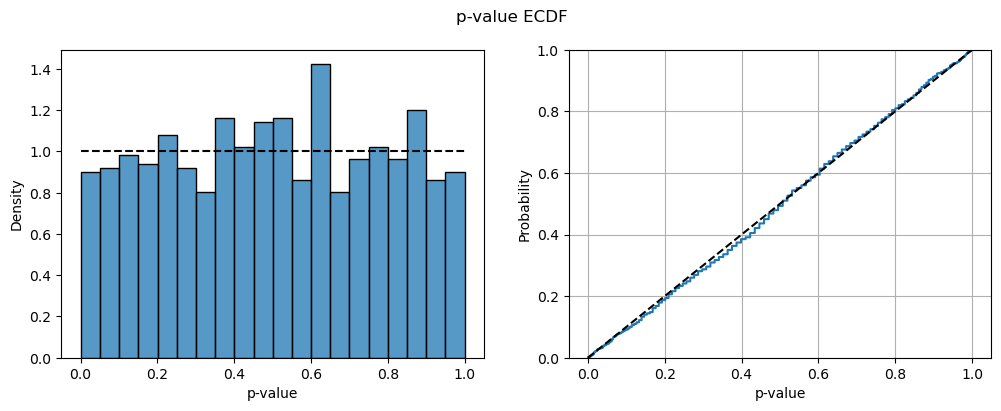

In [185]:
plot_pvalue_ecdf(p_values, 'p-value ECDF')

* затем запущу 1000 аналогичных тестов, прибавив эффект во вторую группу, чтобы проконтроллировать уровень ошибки II рода

In [187]:
p_values2 = []
p1 = two_weeks_data['is_applied'].mean()
mde = mde
p2 = p1 + mde

for i in range(1000):

    users_shuffled = users.copy()
    np.random.shuffle(users_shuffled)

    group_a = users_shuffled[:len(users_shuffled)//2]
    group_b = users_shuffled[len(users_shuffled)//2:]

    data_a = two_weeks_data[two_weeks_data['visitor_id'].isin(group_a)].copy()
    data_b = two_weeks_data[two_weeks_data['visitor_id'].isin(group_b)].copy()

    # синтетический эффект
    data_b['is_applied'] = np.random.binomial(1, p2, len(data_b))

    count = [data_a['is_applied'].sum(), data_b['is_applied'].sum()]
    nobs = [len(data_a), len(data_b)]

    stat, p_value = proportions_ztest(count, nobs, alternative='smaller')
    p_values2.append(p_value)
    type_2_error_rate = np.mean(np.array(p_values2) > 0.05)

print(f'Нулевая гипотеза ошибочно НЕ отвергнута в {type_2_error_rate*100}%')

Нулевая гипотеза ошибочно НЕ отвергнута в 13.8%


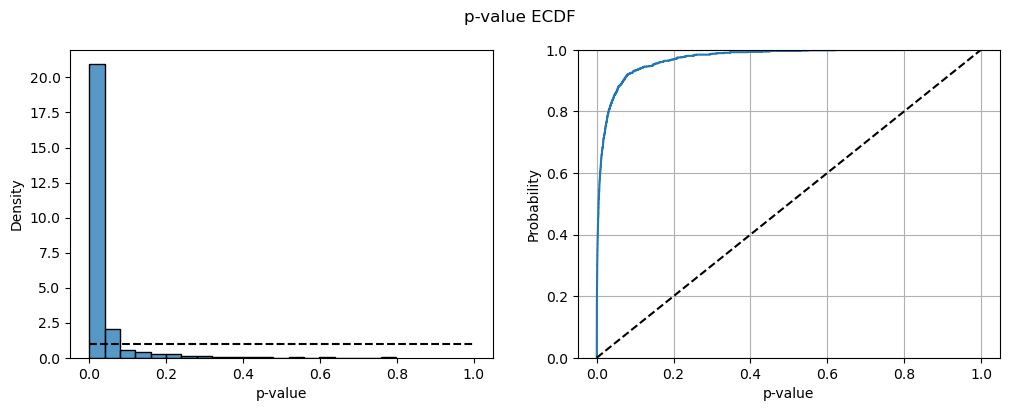

In [188]:
plot_pvalue_ecdf(p_values2, 'p-value ECDF')

Проведем синтетический АБ-тест (реализуем ту же логику со сдвигом ретроспективы)

In [190]:
synth_data = dataset[
        (dataset['date_time'] >= '2025-03-17') &
        (dataset['date_time'] < '2025-03-30')
]
synth_visitors = synth_data['visitor_id'].unique()
np.random.seed(23) # fix the random indexes
np.random.shuffle(synth_visitors)
synth_a_group = synth_visitors[:len(synth_visitors)//2]
synth_b_group = synth_visitors[len(synth_visitors)//2:]

a = synth_data[synth_data['visitor_id'].isin(synth_a_group)].copy()
b = synth_data[synth_data['visitor_id'].isin(synth_b_group)].copy()
b['is_applied'] = np.random.binomial(1, p2, len(b))

count = [a['is_applied'].sum(), b['is_applied'].sum()]
nobs = [len(a), len(b)]

stat, p_value = proportions_ztest(count, nobs, alternative='smaller')
print(f'z_statistics = {stat}, p_value = {p_value}')

z_statistics = -2.4837987488050954, p_value = 0.006499462403802176


## Данные эксперимента

In [192]:
exp_data = pd.read_csv('experiment_data.csv')

In [199]:
exp_group_treatment = exp_data[exp_data['form_variant'] == 'test']
exp_group_control = exp_data[exp_data['form_variant'] == 'control']
print(f'treatment size: {exp_group_treatment.shape[0]}')
print(f'control size: {exp_group_control.shape[0]}')

treatment size: 17912
control size: 17800


### SRM-check

In [202]:
observed = [exp_group_treatment.shape[0], exp_group_control.shape[0]]
expected = [int(np.floor(exp_data.shape[0]/2)), int(np.floor(exp_data.shape[0]/2))]

stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(p_value)

0.5534038568471811


p-value > 0.05, следовательно, размеры выборок корректны

### Конверсия тестовой группы

In [206]:
exp_tr_cr = exp_group_treatment['is_applied'].mean()
exp_tr_cr

0.18730460026797677

### Конверсия контрольной группы

In [209]:
exp_cn_cr = exp_group_control['is_applied'].mean()
exp_cn_cr

0.15084269662921349

### Uplift

In [212]:
uplift = exp_tr_cr - exp_cn_cr
uplift

0.03646190363876328

In [214]:
tr_counts = exp_group_treatment['is_applied'].sum()
tr_obs = exp_group_treatment['is_applied'].count()
cn_counts = exp_group_control['is_applied'].sum()
cn_obs = exp_group_control['is_applied'].count()

In [216]:
counts = [cn_counts, tr_counts]
nobs = [cn_obs , tr_obs]
z_stat, p_value = proportions_ztest(counts, nobs, alternative='smaller')
print(f'z_statistics = {z_stat}, p_value = {p_value}')

z_statistics = -9.190445995488648, p_value = 1.956079595325949e-20


### Доверительный интервал

In [218]:
c = norm.ppf(1-alpha/2)
se = np.sqrt((exp_cn_cr*(1-exp_cn_cr)/exp_group_control.shape[0] \
              + (exp_tr_cr*(1-exp_tr_cr))/exp_group_treatment.shape[0])
            )
ci_floor = uplift - c*se
ci_ceil = uplift + c*se
print(f'[{ci_floor:.3f}, {ci_ceil:.3f}]')

[0.029, 0.044]


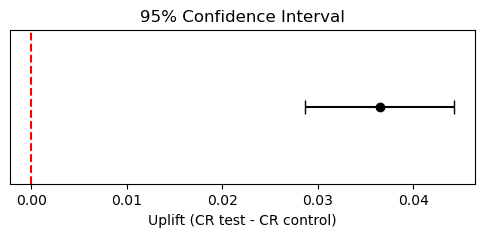

In [297]:
plt.figure(figsize=(6, 2))

plt.errorbar(
    x=uplift,
    y=0,
    xerr=[[uplift - ci_floor], [ci_ceil - uplift]],
    fmt='o',
    color='black',
    capsize=5
)

plt.axvline(0, color='red', linestyle='--')

plt.yticks([])
plt.xlabel('Uplift (CR test - CR control)')
plt.title('95% Confidence Interval')

plt.show()

## Прокси-метрика: CTR кнопки

In [237]:
proxy_treatment = exp_group_treatment['clicked_connect'].sum() / exp_group_treatment.shape[0]
proxy_treatment

0.3624944171505136

In [239]:
proxy_control = exp_group_control['clicked_connect'].sum() / exp_group_control.shape[0]
proxy_control

0.3043820224719101

In [287]:
delta = 0  # допустимое ухудшение 1 п.п.

# скорректированная разница
diff = proxy_treatment - proxy_control + delta

# стандартная ошибка
se = np.sqrt(
    proxy_treatment*(1-proxy_treatment)/exp_group_treatment.shape[0] +
    proxy_control*(1-proxy_control)/exp_group_control.shape[0]
)

z_stat = diff / se
p_value = 1 - norm.cdf(z_stat)

print(z_stat, p_value)

11.670031541065287 0.0


p-value прокси-метрики равен 0, что означает, что нет статзначимых ухудшений метрики (в тесте она наоборот выросла). Таким образом, по результатам теста:
* uplift ключевой метрики в тестовой группе составил 3,64 п.п. конверсии
* p-value этой разницы равен 1.95e-20, что позволяет отклонить нулевую гипотезу на уровне значимости 0.05
* 95%-й доверительный интервал не покрывает 0, что подтверждает уверенность в точечной оценке
* прокси-метрика в тестовой группе оказалась также выше